In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, recall_score, confusion_matrix, ConfusionMatrixDisplay



In [31]:
df_train = pd.read_parquet('train.parquet')
df_test = pd.read_parquet('test.parquet')

In [32]:
# df_user = df_train.groupby('userId').agg(
#     churn_flag=('churn_flag', 'max'),
#     pages=('page', lambda x: list(x))
# )

# all_pages = ['NextSong', 'Downgrade', 'Help', 'Home', 'Thumbs Up', 
#              'Add Friend', 'Thumbs Down', 'Add to Playlist', 'Logout',
#              'About', 'Settings', 'Save Settings', 'Cancel', 
#              'Cancellation Confirmation', 'Submit Downgrade', 'Roll Advert',
#              'Upgrade', 'Error', 'Submit Upgrade']

# for p in all_pages:
#     df_user[p] = df_user['pages'].apply(lambda x: int(p in x))

# X = df_user[all_pages]
# y = df_user['churn_flag']

# clf = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)
# clf.fit(X, y)

# coef_table = pd.DataFrame({
#     'page': X.columns,
#     'coef': clf.coef_[0],
#     'odds_ratio': np.exp(clf.coef_[0])
# }).sort_values('odds_ratio', ascending=False)

# print(coef_table)


# Chi^2 test for checking feature significance (here status, but used previously for others)
# contingency = pd.crosstab(df_train['status'], df_train['churn_flag'])

# # run chi-square test
# chi2, p, dof, expected = chi2_contingency(contingency)

# print("Chi-square statistic:", chi2)
# print("Degrees of freedom:", dof)
# print("p-value:", p)



In [33]:
# Weights from Logistic Regression model (Done above)
churn_pages = {
    'Cancel': 7,
    'Cancellation Confirmation': 7,
    'Downgrade': 0.16,
    'Submit Upgrade': 0.14,
    'Upgrade': 0.03,
    'Settings': 0.02,
    'Submit Downgrade': 0.01
}
retain_pages = {
    'Save Settings': -0.0007,
    'Thumbs Down': -0.016,
    'About': -0.054,
    'Help': -0.058,
    'Add Friend': -0.158,
    'Add to Playlist': -0.383,
    'Roll Advert': -0.422,
    'Thumbs Up': -0.716,
    'Home': -1.423,
    'NextSong': -1.925
}

def compute_cumulative_risk(user_df):
    churn_score = 0
    not_churn_score = 0
    churn_list = []
    not_churn_list = []
        
    for page in user_df['page']:
        churn_score += churn_pages.get(page, 0)
        not_churn_score += retain_pages.get(page, 0)
        churn_list.append(churn_score)
        not_churn_list.append(not_churn_score)
        
    user_df['churn_risk_score'] = churn_list
    user_df['not_churn_score'] = not_churn_list
    return user_df


def forward_looking_churn(df, prediction_window_days=10, buffer_days=0):
    df = df.sort_values(['userId', 'ts']).reset_index(drop=True)
    
    churn_events = df[df['churn_flag'] == 1].groupby('userId')['ts'].min().reset_index()
    churn_events.columns = ['userId', 'churn_time']
    
    df = df.merge(churn_events, on='userId', how='left')
    
    df['days_until_churn'] = (df['churn_time'] - df['ts']).dt.total_seconds() / 86400
    
    
    df['will_churn_in_10d'] = (
        (df['days_until_churn'] >= 0) &
        (df['days_until_churn'] <= prediction_window_days)
    ).astype(int)
    
    df['will_churn_in_10d'] = df['will_churn_in_10d'].fillna(0).astype(int)
    
    
    if buffer_days > 0:
        mask_keep = (df['days_until_churn'].isna()) | (df['days_until_churn'] > buffer_days)
        df_clean = df[mask_keep].copy()
    else:
        mask_keep = (df['days_until_churn'].isna()) | (df['days_until_churn'] > 0)
        df_clean = df[mask_keep].copy()
    
    def filter_non_churner_tail(user_df):
        if user_df['churn_time'].isna().all():
            max_time = user_df['ts'].max()
            cutoff = max_time - pd.Timedelta(days=prediction_window_days)
            return user_df[user_df['ts'] <= cutoff]
        return user_df
    
    df_clean = df_clean.groupby('userId', group_keys=False).apply(filter_non_churner_tail)
    
    df_clean = df_clean.drop(columns=['churn_time', 'days_until_churn', 'churn_flag'])
    
    return df_clean.reset_index(drop=True)


def feature_engineering(df, prediction_window_days=10, buffer_days=0):
    df['churn_flag'] = ((df['auth'] == 'Cancelled') | 
                        (df['page'] == 'Cancellation Confirmation')).astype(int)
    
    df['ts'] = pd.to_datetime(df['ts'], unit='ms')
    df = df.sort_values(['userId', 'ts']).reset_index(drop=True)
    
    df['churn_risk_score'] = 0.0
    df['not_churn_score'] = 0.0
    
    df['level'] = df['level'].map({'free': 0, 'paid': 1})
    
    df['timeInSession'] = df.groupby('userId')['ts'].transform(
        lambda x: (x - x.min()).dt.total_seconds()
    )
    df['timeSinceRegistered'] = (df['ts'] - df['registration']).dt.total_seconds()
    
    df = df.groupby('userId', group_keys=False).apply(compute_cumulative_risk)
    
    df = forward_looking_churn(df, prediction_window_days, buffer_days)
    
    feats_kept = ['status', 'level', 'userId', 'itemInSession', 'timeSinceRegistered', 
                  'not_churn_score', 'churn_risk_score', 'timeInSession', 'ts']
    
    df_seq = df[feats_kept + ['will_churn_in_10d']].copy()
    
    # Diagnostic info
    print(f"Total rows after cleaning: {len(df_seq)}")
    print(f"Number of users: {df_seq['userId'].nunique()}")
    print(f"Churn rate (will churn in next {prediction_window_days} days): {df_seq['will_churn_in_10d'].mean():.2%}")
    print(f"Class distribution:\n{df_seq['will_churn_in_10d'].value_counts()}")
    
    user_churn = df_seq.groupby('userId')['will_churn_in_10d'].max()
    print(f"\nUsers who will churn: {user_churn.sum()}")
    print(f"Users who won't churn: {len(user_churn) - user_churn.sum()}")
    
    return df_seq


In [34]:
df_train = feature_engineering(df_train, buffer_days=1) # Remove leakage
df_test = feature_engineering(df_test)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

Total rows after cleaning: 12984498
Number of users: 17178
Churn rate (will churn in next 10 days): 10.05%
Class distribution:
will_churn_in_10d
0    11678917
1     1305581
Name: count, dtype: int64

Users who will churn: 3519
Users who won't churn: 13659
Total rows after cleaning: 3262600
Number of users: 2773
Churn rate (will churn in next 10 days): 0.00%
Class distribution:
will_churn_in_10d
0    3262600
Name: count, dtype: int64

Users who will churn: 0
Users who won't churn: 2773


In [35]:
df_train[df_train['userId'] == '1000025']

,status,level,userId,itemInSession,timeSinceRegistered,not_churn_score,churn_risk_score,timeInSession,ts,will_churn_in_10d
0,200,0,1000025,0,7255761.0,-1.4230,0.00,0.0,2018-10-02 08:59:29,0
1,200,0,1000025,1,7255956.0,-3.3480,0.00,195.0,2018-10-02 09:02:44,0
2,200,0,1000025,2,7256207.0,-5.2730,0.00,446.0,2018-10-02 09:06:55,0
3,200,0,1000025,3,7256430.0,-7.1980,0.00,669.0,2018-10-02 09:10:38,0
4,200,0,1000025,4,7256623.0,-9.1230,0.00,862.0,2018-10-02 09:13:51,0
...,...,...,...,...,...,...,...,...,...,...
1748,200,1,1000025,137,8592480.0,-2973.4084,3.01,1336719.0,2018-10-17 20:18:08,1
1749,200,1,1000025,138,8592751.0,-2975.3334,3.01,1336990.0,2018-10-17 20:22:39,1
1750,200,1,1000025,139,8592936.0,-2977.2584,3.01,1337175.0,2018-10-17 20:25:44,1
1751,307,1,1000025,140,8592937.0,-2977.9744,3.01,1337176.0,2018-10-17 20:25:45,1


In [36]:
# # Basic and Naive EDA
# num_cols = df_train.select_dtypes(include=["int64", "float64"]).columns

# # Histograms
# for col in num_cols:
#     plt.figure()
#     df_train[col].hist()
#     plt.title(f"Histogram of {col}")
#     plt.xlabel(col)
#     plt.ylabel("Frequency")
#     plt.show()

# # Box plots
# for col in num_cols:
#     plt.figure()
#     df_train.boxplot(column=col)
#     plt.title(f"Box plot of {col}")
#     plt.ylabel(col)
#     plt.show()

In [37]:
models = {
    "logistic_regression": LogisticRegression(random_state=42, max_iter=10000),
    "decision_tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random_forest": RandomForestClassifier(
        n_estimators=150, max_depth=4, random_state=42
    ),
    "GBDT": GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=200, max_depth=5, random_state=42),
    "ridge_regression": RidgeClassifier(random_state=42),
    "knn": KNeighborsClassifier(n_neighbors=5),
}

In [ ]:
# Split by User to keep time series integrity

unique_users = df_train['userId'].unique()
train_users, val_users = train_test_split(unique_users, test_size=0.2, random_state=42)

train_mask = df_train['userId'].isin(train_users)
val_mask = df_train['userId'].isin(val_users)

X_train = df_train[train_mask].drop(columns=["will_churn_in_10d", "userId", "ts"])
y_train = df_train[train_mask]["will_churn_in_10d"]

X_val = df_train[val_mask].drop(columns=["will_churn_in_10d", "userId", "ts"])
y_val = df_train[val_mask]["will_churn_in_10d"]


KeyError: 0

For Model: logistic_regression
For Training Set:
Macro F1 Score: 0.4758123219503342
Confusion Matrix:


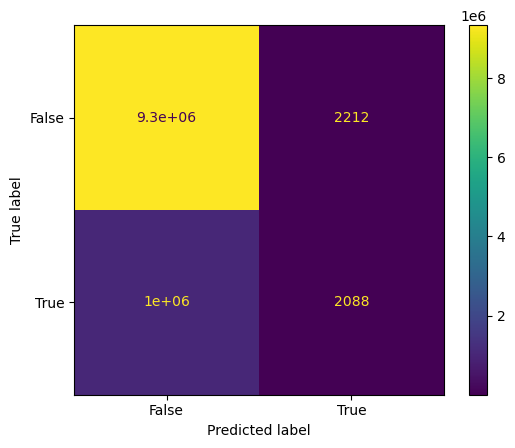

For Validation Set:
Macro F1 Score: 0.47243264483248404
Confusion Matrix:


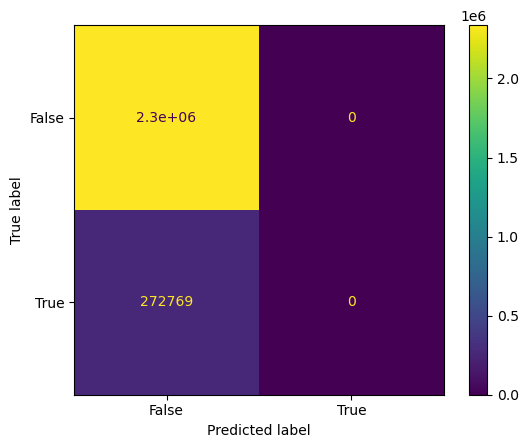

For Model: decision_tree
For Training Set:
Macro F1 Score: 0.5332423619088209
Confusion Matrix:


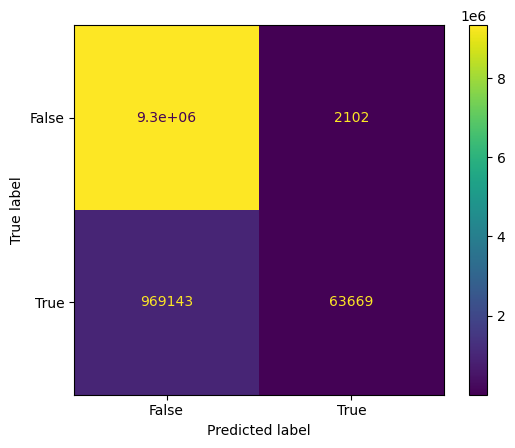

For Validation Set:
Macro F1 Score: 0.53008083491724
Confusion Matrix:


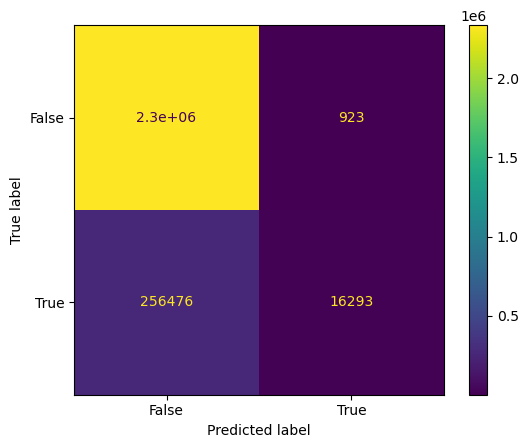

For Model: Random_forest
For Training Set:
Macro F1 Score: 0.5295027223542345
Confusion Matrix:


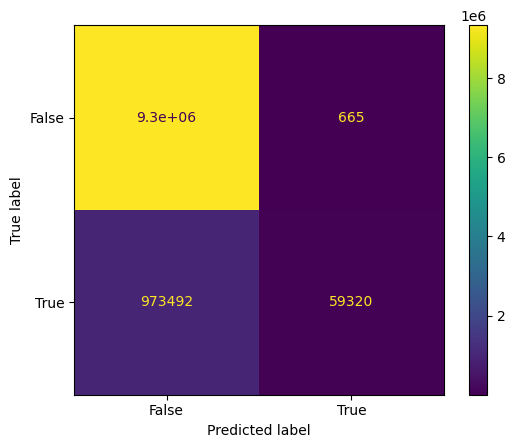

For Validation Set:
Macro F1 Score: 0.5287995986834758
Confusion Matrix:


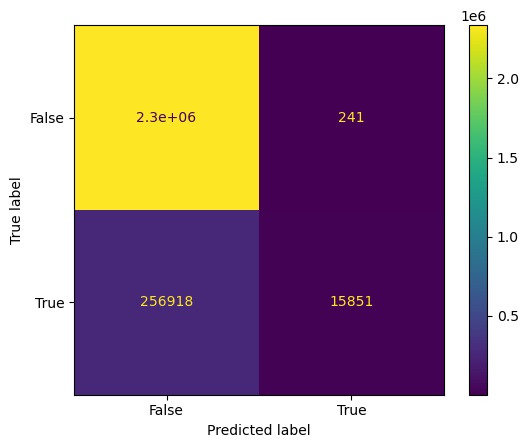

For Model: GBDT


In [ ]:
train_scores = []
test_scores = []
recall_test_scores = []

model_names = models.keys()

for model in model_names:
    print("For Model:", model)

    models[model].fit(X_train, y_train)

    print("For Training Set:")

    y_train_pred = models[model].predict(X_train)

    f1_train = f1_score(y_train, y_train_pred, average="macro")
    print("Macro F1 Score:", f1_train)

    print("Confusion Matrix:")
    conf_matrix = confusion_matrix(y_train, y_train_pred)
    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=conf_matrix, display_labels=[False, True]
    )
    cm_display.plot()
    plt.show()

    print("For Validation Set:")

    y_test_pred = models[model].predict(X_val)

    f1_test = f1_score(y_val, y_test_pred, average="macro")
    print("Macro F1 Score:", f1_test)

    recall_test_score = recall_score(y_val, y_test_pred, average="macro")

    print("Confusion Matrix:")
    conf_matrix = confusion_matrix(y_val, y_test_pred)
    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=conf_matrix, display_labels=[False, True]
    )
    cm_display.plot()
    plt.show()

    train_scores.append(f1_train)
    test_scores.append(f1_test)
    recall_test_scores.append(recall_test_score)



In [ ]:
# Worth trying hyperparameter tuning for XGBoost and also Light GB

# from sklearn.model_selection import GridSearchCV

# xgb_params = {
#     'max_depth': [4, 5, 6, 7],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'n_estimators': [200, 300, 500],
#     'scale_pos_weight': [len(y_train[y_train==0]) / len(y_train[y_train==1])],  # Handle imbalance
#     'subsample': [0.8, 0.9],
#     'colsample_bytree': [0.8, 0.9]
# }

# xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
# grid_search = GridSearchCV(xgb_model, xgb_params, cv=3, scoring='f1_macro', n_jobs=-1)
# grid_search.fit(X_train, y_train)

# print(f"Best params: {grid_search.best_params_}")
# print(f"Best F1: {grid_search.best_score_}")

# import lightgbm as lgb

# lgb_model = lgb.LGBMClassifier(
#     n_estimators=500,
#     max_depth=6,
#     learning_rate=0.05,
#     num_leaves=31,
#     scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
#     random_state=42
# )

# lgb_model.fit(X_train, y_train)
# y_val_pred = lgb_model.predict(X_val)
# print(f"LightGBM F1: {f1_score(y_val, y_val_pred, average='macro')}")

In [ ]:
Tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
gbdt_model = GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=42)

Tree_model.fit(X_train, y_train)
gbdt_model.fit(X_train, y_train)

y_pred_proba_tree = [x[1] for x in Tree_model.predict_proba(X_val)]
y_pred_proba_gbdt = [x[1] for x in gbdt_model.predict_proba(X_val)]
y_pred_proba_tree = np.array(y_pred_proba_tree)
y_pred_proba_gbdt = np.array(y_pred_proba_gbdt)


y_pred_proba = (y_pred_proba_tree + y_pred_proba_gbdt) / 2.0

y_pred = np.where(y_pred_proba > 0.4, 1, 0)

f1 = f1_score(y_val, y_pred, average="macro")
print("Macro F1 Score:", f1)

recall = recall_score(y_val, y_pred, average="macro")
print("Macro Recall Score:", recall)

print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_val, y_pred)
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix, display_labels=[False, True]
)
cm_display.plot()
plt.show()

In [ ]:



tree_scores = cross_val_score(Tree_model, X_train, y_train, cv=5, scoring="f1_macro")
#gbdt_scores = cross_val_score(gbdt_model, X_train, y_train, cv=5, scoring="f1_macro")
print("Decision Tree CV Macro F1 Scores:", tree_scores)
#print("Gradient Boosting CV Macro F1 Scores:", gbdt_scores)


# faudrait faire deux predictions separées et apres submit les deux
# apres on peut aussi submit celle qui est combinée
